In [40]:
import os
from pathlib import Path
import scanpy as sc
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
from pathlib import Path

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../results/figures")

In [42]:
matrix_files = list(RAW_DIR.glob("*_matrix.mtx.gz"))
len(matrix_files)

15

In [43]:
def load_sample(matrix_file):
    base = matrix_file.name.replace("_matrix.mtx.gz", "")
    
    barcodes = RAW_DIR / f"{base}_barcodes.tsv.gz"
    features = RAW_DIR / f"{base}_features.tsv.gz"
    
    # Load matrix
    adata = sc.read_mtx(matrix_file).T
    
    # Load gene names
    genes = pd.read_csv(features, sep="\t", header=None)
    adata.var["gene_symbols"] = genes[1].values
    adata.var_names = adata.var["gene_symbols"]
    
    # Load cell barcodes
    cells = pd.read_csv(barcodes, sep="\t", header=None)
    adata.obs_names = cells[0].values
    
    # Fix duplicate gene names
    adata.var_names_make_unique()
    
    return adata


In [44]:
adata_test = load_sample(matrix_files[0])
adata_test.shape # how many rows and columns
adata_test.obs_names[:5] # cell names
adata_test.var_names[:5] # gene names


Index(['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3'], dtype='object', name='gene_symbols')

In [45]:
adatas = []

for matrix_file in matrix_files:
    adata = load_sample(matrix_file)
    
    sample_base = matrix_file.name.replace("_matrix.mtx.gz", "")
    
    if "before" in sample_base:
        condition = "before_IVIG"
    elif "after" in sample_base:
        condition = "after_IVIG"
    elif "health" in sample_base:
        condition = "healthy"
    else:
        condition = "unknown"
    
    adata.obs["sample_id"] = sample_base
    adata.obs["condition"] = condition
    
    adatas.append(adata)

len(adatas)

15

In [46]:
adata = ad.concat(adatas, join="outer")
adata

/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 106453 × 33538
    obs: 'sample_id', 'condition'

In [47]:
print(adata.shape)

print(adata.obs["condition"].value_counts())

print(adata.obs["sample_id"].value_counts().head())

(106453, 33538)
condition
after_IVIG     52802
before_IVIG    37403
healthy        16248
Name: count, dtype: int64
sample_id
GSM5160428_P5_after     10588
GSM5160425_P4_after     10394
GSM5160421_P2_after      9910
GSM5160423_P3_after      8867
GSM5160427_P5_before     8790
Name: count, dtype: int64


In [48]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["mt"].value_counts()

mt
False    33525
True        13
Name: count, dtype: int64

In [49]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
adata.obs.head()

,sample_id,condition,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
AAACCTGAGGTCATCT-1,GSM5160420_P2_before,before_IVIG,1071,6.977281,2906.0,7.974877,43.805919,56.951136,66.964900,80.350998,141.0,4.955827,4.852030
AAACCTGCACAGGTTT-1,GSM5160420_P2_before,before_IVIG,1271,7.148346,3390.0,8.128881,41.533923,54.867257,64.336283,77.256637,77.0,4.356709,2.271386
AAACCTGCAGATGAGC-1,GSM5160420_P2_before,before_IVIG,1187,7.080026,4194.0,8.341649,50.691464,64.735336,73.700525,83.619456,111.0,4.718499,2.646638
AAACCTGCAGGTCTCG-1,GSM5160420_P2_before,before_IVIG,1476,7.297768,4450.0,8.400884,41.550562,55.235955,65.348315,78.067416,125.0,4.836282,2.808989
AAACCTGGTCGACTAT-1,GSM5160420_P2_before,before_IVIG,2526,7.834788,23260.0,10.054533,70.472915,77.171109,82.308684,88.301806,838.0,6.732211,3.602751


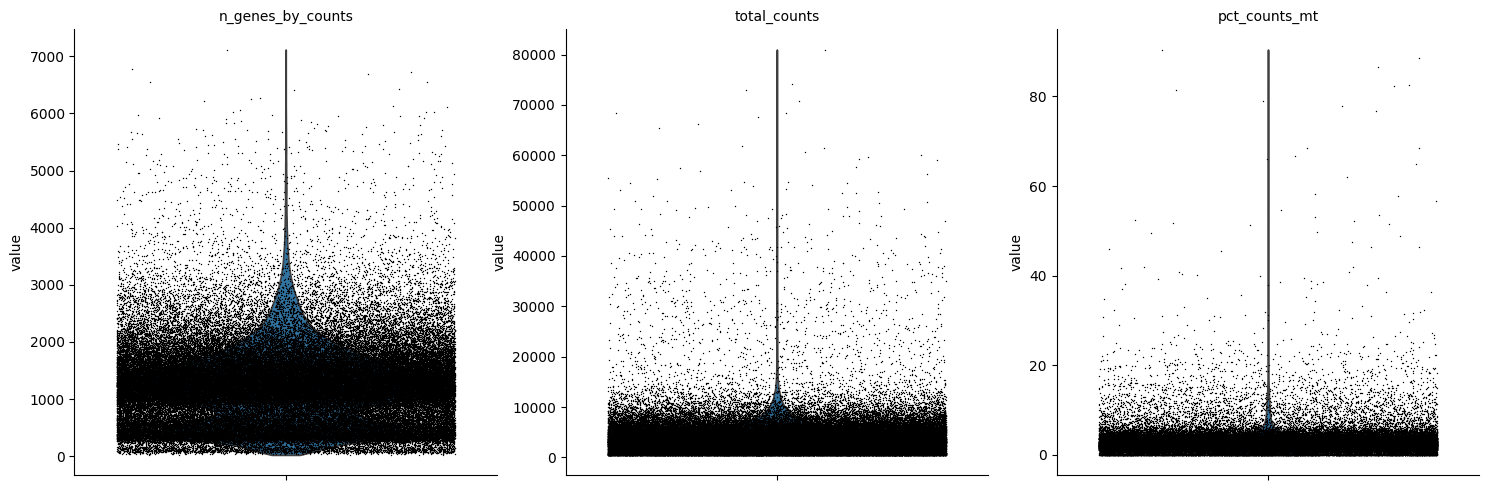

In [50]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [51]:
# Keep good cells
adata = adata[adata.obs.n_genes_by_counts > 200, :]
adata = adata[adata.obs.n_genes_by_counts < 6000, :]
adata = adata[adata.obs.pct_counts_mt < 10, :]

In [52]:
sc.pp.filter_genes(adata, min_cells=3)

/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:278: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number
/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [53]:
adata.shape

(101804, 21813)

In [54]:
adata.write("../data/processed/adata_qc_filtered.h5ad")

In [55]:
sc.pp.normalize_total(adata, target_sum=1e4)

In [56]:
sc.pp.log1p(adata)

In [57]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata.var["highly_variable"].value_counts()

highly_variable
False    19813
True      2000
Name: count, dtype: int64

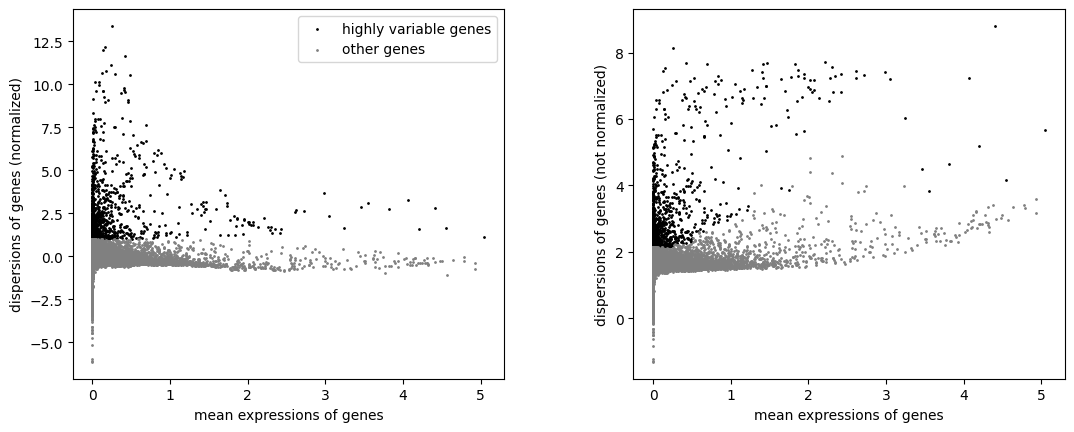

In [58]:
sc.pl.highly_variable_genes(adata)

In [59]:
adata = adata[:, adata.var.highly_variable]
adata.shape

(101804, 2000)

In [60]:
sc.pp.scale(adata, max_value=10)

/Users/shamithakv/miniforge3/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/shamithakv/miniforge3/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [61]:
sc.tl.pca(adata, svd_solver='arpack')

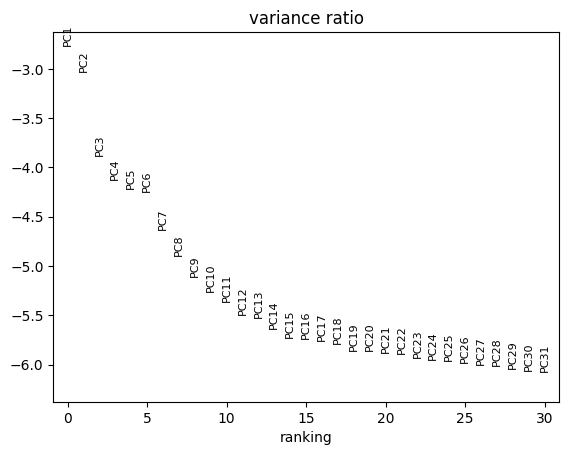

In [62]:
sc.pl.pca_variance_ratio(adata, log=True)

In [63]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)

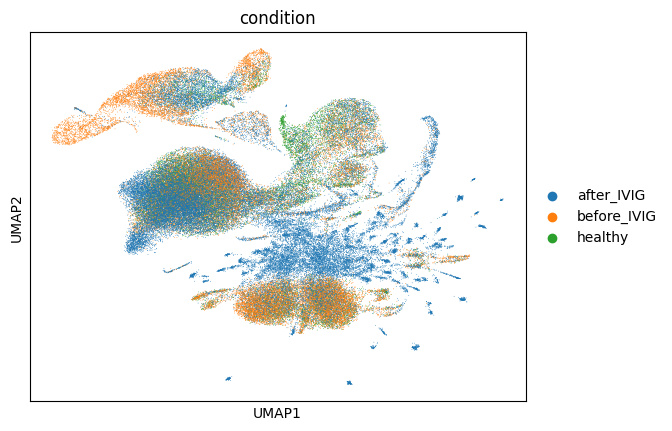

In [64]:
sc.tl.umap(adata)
sc.pl.umap(adata, color=["condition"])

/var/folders/sp/k707q_0j2qz5mz_7w6zq4znh0000gn/T/ipykernel_18989/2276071930.py:1: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5)


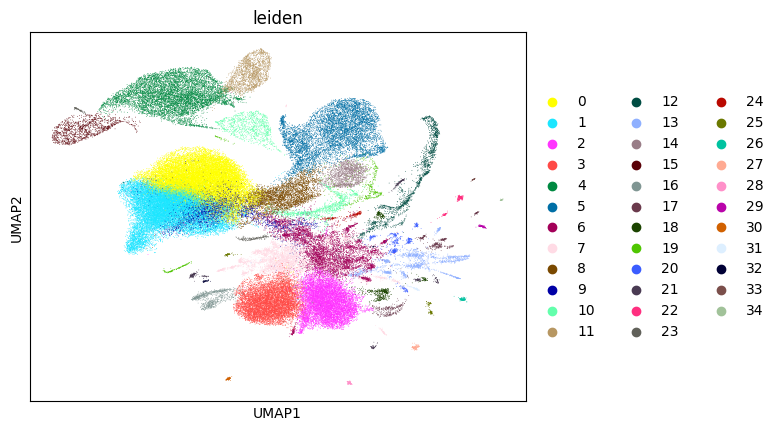

In [65]:
sc.tl.leiden(adata, resolution=0.5)
sc.pl.umap(adata, color=["leiden"])

In [66]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes

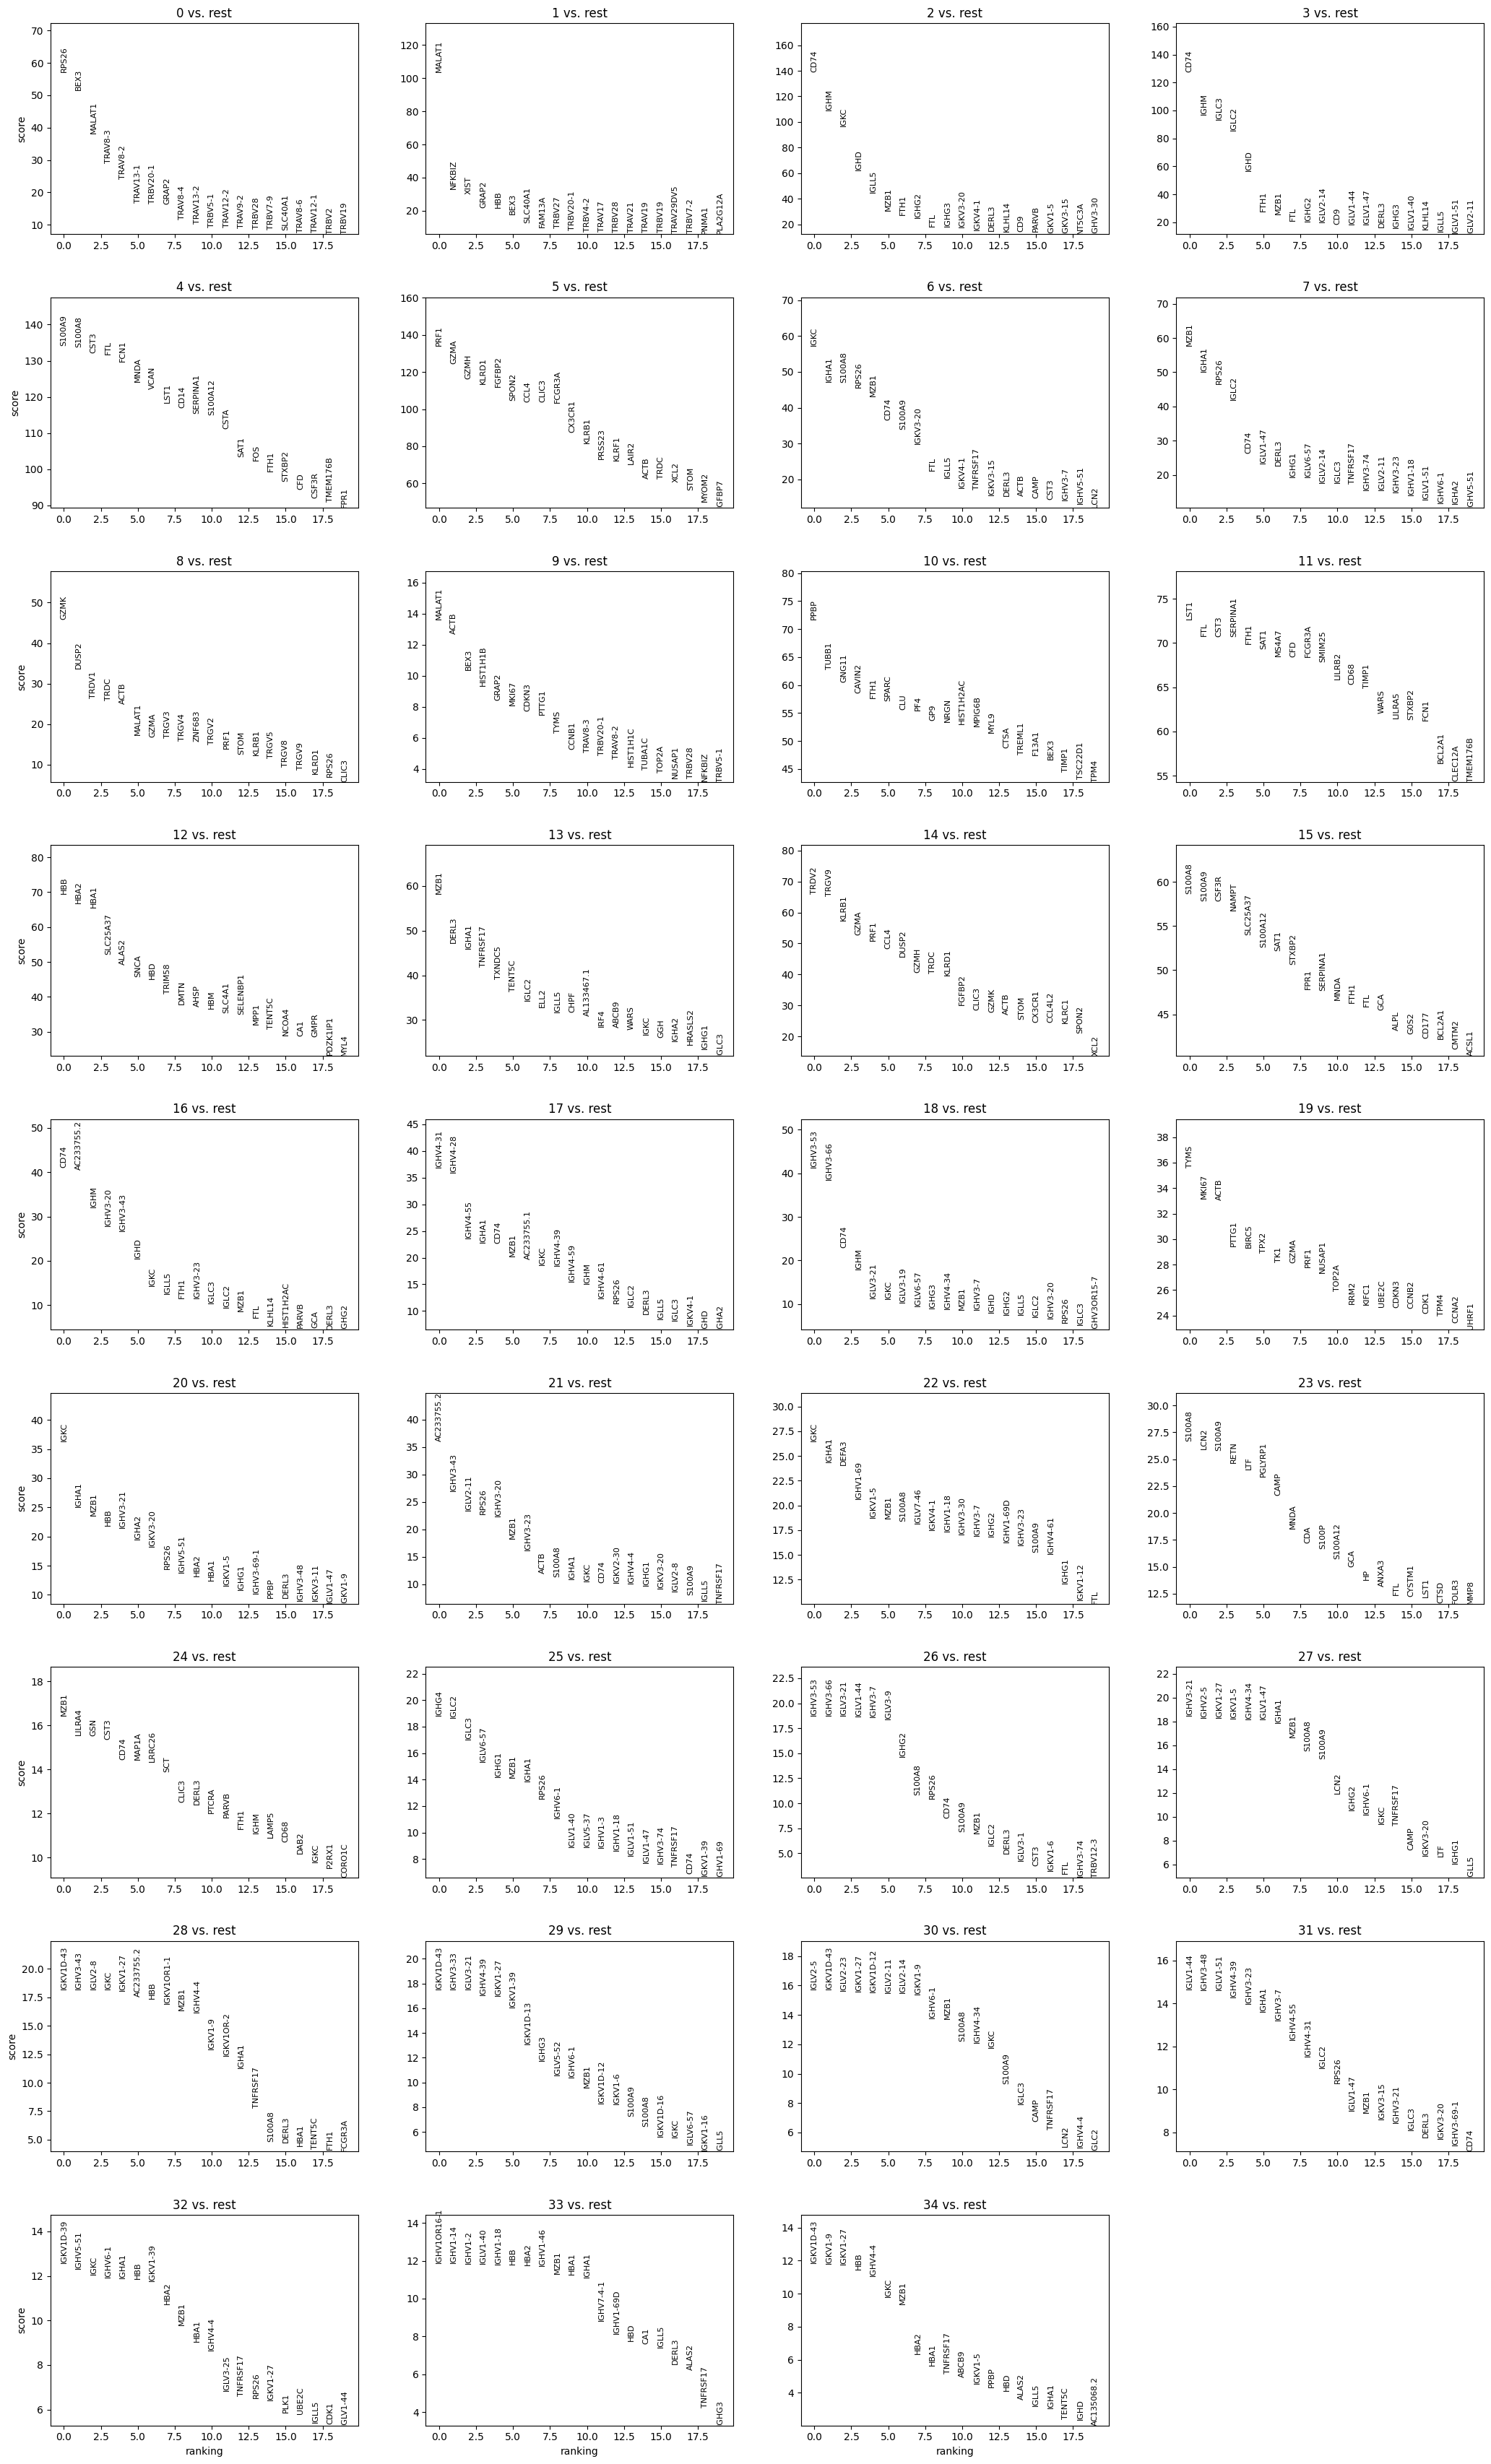

In [67]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

In [68]:
cell_type_map = {
    "0": "T cells",
    "1": "Activated T cells",
    "2": "B cells",
    "3": "B cells",
    "4": "Monocytes",
    "5": "NK cells",
    "6": "B cells",
    "7": "Plasma cells",
    "8": "γδ T cells",
    "9": "Proliferating cells",
    "10": "Platelets",
    "11": "Monocytes",

    "12": "RBC (contamination)",
    "13": "Plasma cells",
    "14": "γδ T cells",
    "15": "Monocytes",

    "16": "B cells",
    "17": "B cells",
    "18": "B cells",
    "19": "Proliferating cells",
    "20": "B cells",
    "21": "B cells",
    "22": "B cells",
    "23": "Monocytes",

    "24": "B cells",
    "25": "B cells",
    "26": "B cells",
    "27": "B cells",
    "28": "B cells",
    "29": "B cells",
    "30": "B cells",
    "31": "B cells",
    "32": "B cells",
    "33": "B cells",
    "34": "B cells"
}

/var/folders/sp/k707q_0j2qz5mz_7w6zq4znh0000gn/T/ipykernel_18989/342052705.py:3: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


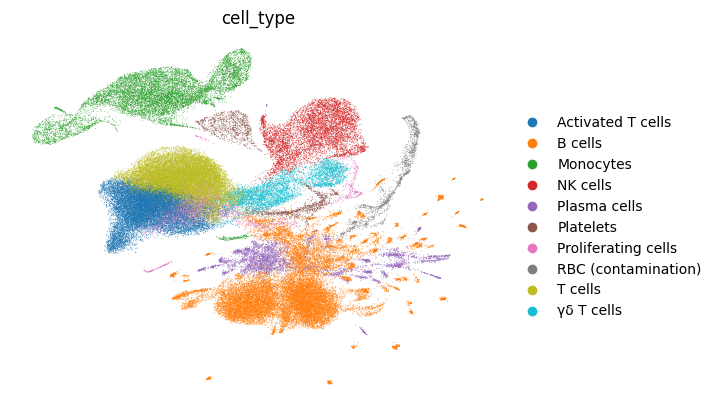

In [69]:
adata.obs["cell_type"] = adata.obs["leiden"].map(cell_type_map)

sc.pl.umap(
    adata,
    color=["cell_type"],
    legend_loc="right margin",
    frameon=False,
    save="_cell_types.png"
)

In [70]:
celltype_counts = pd.crosstab(adata.obs["condition"], adata.obs["cell_type"])
celltype_counts

cell_type,Activated T cells,B cells,Monocytes,NK cells,Plasma cells,Platelets,Proliferating cells,RBC (contamination),T cells,γδ T cells
condition,,,,,,,,,,
after_IVIG,9610,13704,3773,2506,4893,1634,2142,1456,7816,2093
before_IVIG,5559,11079,5881,2197,475,590,909,224,7658,1490
healthy,2683,3217,1210,2494,114,41,538,5,4325,1488


In [71]:
celltype_props = celltype_counts.div(celltype_counts.sum(axis=1), axis=0)
celltype_props

cell_type,Activated T cells,B cells,Monocytes,NK cells,Plasma cells,Platelets,Proliferating cells,RBC (contamination),T cells,γδ T cells
condition,,,,,,,,,,
after_IVIG,0.193645,0.276140,0.076027,0.050497,0.098596,0.032926,0.043162,0.029339,0.157495,0.042175
before_IVIG,0.154151,0.307221,0.163080,0.060923,0.013172,0.016361,0.025207,0.006212,0.212356,0.041318
healthy,0.166491,0.199628,0.075085,0.154763,0.007074,0.002544,0.033385,0.000310,0.268383,0.092336


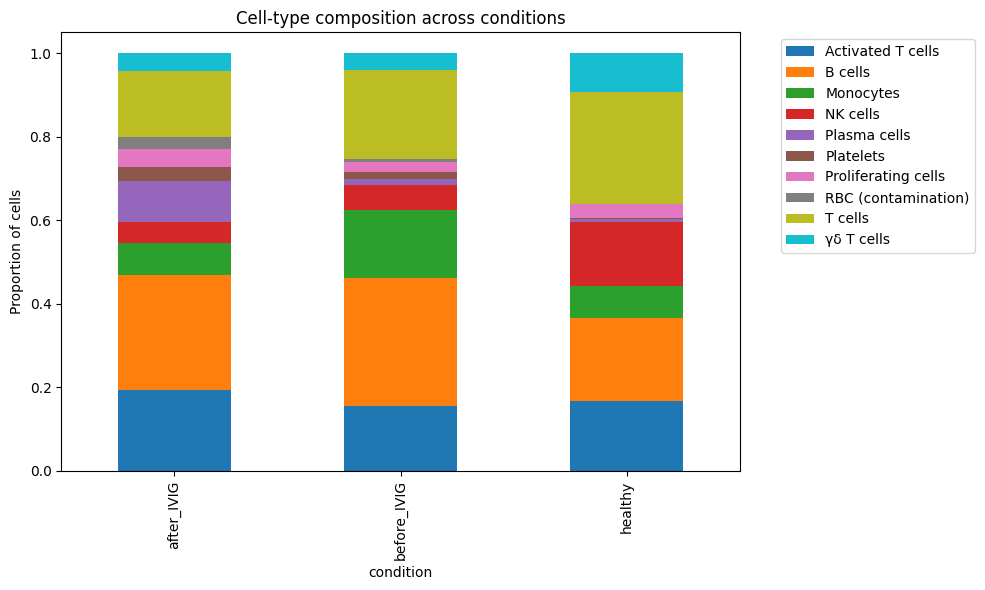

In [72]:
celltype_props.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.ylabel("Proportion of cells")
plt.title("Cell-type composition across conditions")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [73]:
adata_monocytes = adata[adata.obs["cell_type"] == "Monocytes"].copy()

/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [74]:
adata_monocytes.obs["condition"].value_counts()

condition
before_IVIG    5881
after_IVIG     3773
healthy        1210
Name: count, dtype: int64

In [75]:
sc.tl.rank_genes_groups(
    adata_monocytes,
    groupby="condition",
    groups=["before_IVIG"],
    reference="after_IVIG",
    method="wilcoxon"
)

/Users/shamithakv/Desktop/scrna-kawasaki-ivig/venv/lib/python3.12/site-packages/scanpy/tools/_rank_genes_groups.py:483: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


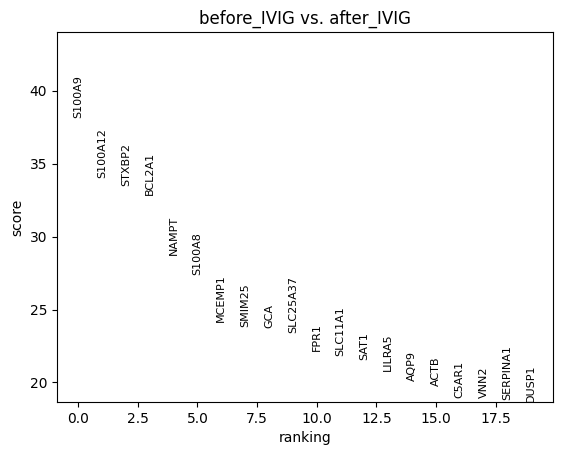

In [76]:
sc.pl.rank_genes_groups(adata_monocytes, n_genes=20, sharey=False)